# Lab 3 Part 2: Customer Churn Prediction

## Step 1: Set-Up + Load and Explore the Data

In [ ]:
# Set-Up
"""
Breast Customer churn prediction with KNN
Author: Carlos Martinez Boto
Description: Predict customer churn for a telecommunications company (customers stop using a company's services).
Predicting churn helps companies take proactive measures to retain customers.
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [12]:
# Import the Telco Customer Churn dataset, Load it into a pandas DataFrame
df = pd.read_csv('data_telco/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Explore the dataset: shape, columns, data types, missing values
print(f"Dataset loaded successfully!")
print(f"\nShape: {df.shape}\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nMissing values and data types:")
print(df.info())

Dataset loaded successfully!

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL          

In [ ]:
# Check the target distribution (how many churned vs. didn't churn)
print("\nTarget distribution (churned):")
print(f"Yes: {(df['Churn'] == 'Yes').sum()}")
print(f"No: {(df['Churn'] == 'No').sum()}")


Target distribution (churned):
Yes: 1869
No: 5174



FEATURE DISTRIBUTIONS
Saved visualization to 'feature_distributions_telco.png'


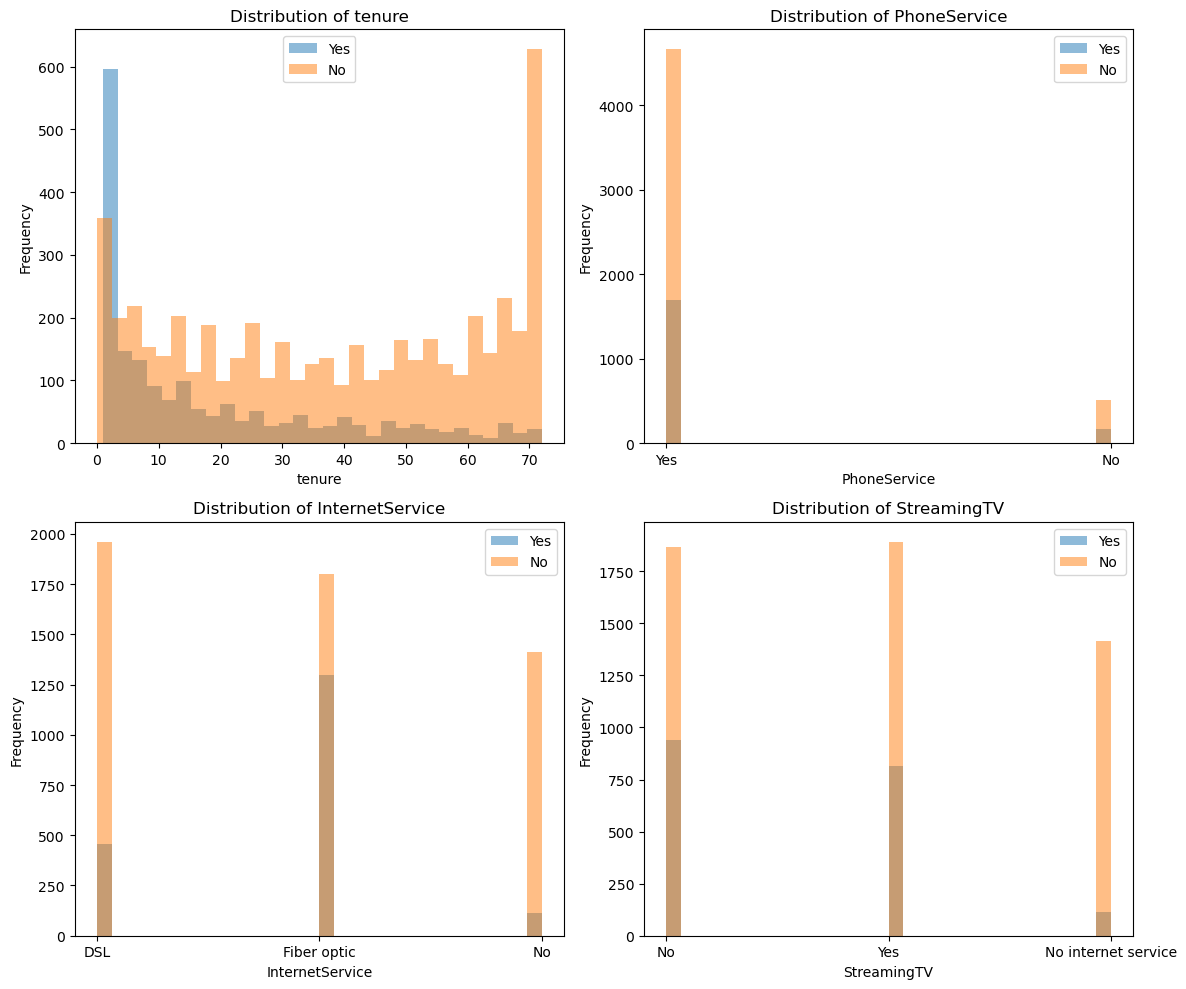

In [18]:
# Visualize some key features
print("\n" + "="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)
 
# Select a few representative features to visualize
key_features = ['tenure', 'PhoneService', 'InternetService', 'StreamingTV']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    axes[idx].hist(df[df['Churn'] == 'Yes'][feature], alpha=0.5, label='Yes', bins=30)
    axes[idx].hist(df[df['Churn'] == 'No'][feature], alpha=0.5, label='No', bins=30)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].legend()
 
plt.tight_layout()
plt.savefig('feature_distributions_telco.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'feature_distributions_telco.png'")
plt.show()

## Step 2: Data Preprocessing

In [19]:
# Handle missing values (if any)
print("✓ No missing values found!")
print("No need for handling mising values")

✓ No missing values found!
No need for handling mising values


In [ ]:
# Convert categorical variables to numeric (use encoding techniques)
df = pd.get_dummies(df, columns=['gender', 'Partner', 'Dependents', 'PhoneService'
                                 'MultipleLines', 'InternetService', 'OnlineSecurity',
                                 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                                 'StreamingTV', 'StreamingMovies', 'Contract',
                                 'PaperlessBilling', 'PaymentMethod', 'Churn'],
                                 drop_first=True)

df = df.select_dtypes(include=[np.number]) # Keep everything that is a number

In [ ]:
# Select relevant features for modeling
# Separate features (X) from target (y)
# Convert target to binary (0/1) if needed